# Bank Marketing — Data Understanding & EDA

## 1. Introduction

### 1.1 Objective & Scope

This notebook establishes the data understanding and evaluation
foundation for the Bank Marketing project.

The objectives are to:

- Inspect the dataset structure and data quality.
- Review feature availability and potential data leakage.
- Establish a reproducible chronological data split.
- Explore training data distributions and feature relationships.
- Document findings, decisions, and limitations for subsequent notebooks.

The business objective is to rank customers by their predicted
probability of subscribing to a term deposit so that limited
call-center resources can prioritize promising customers.

**Prediction time:** immediately before a planned marketing contact.

Preprocessing implementation, baseline model training, and
modeling experiments are handled in subsequent notebooks.

### 1.2 Dataset Overview

This project uses `bank-additional-full.csv` from the
[UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing).

This dataset version contains:

- 41,188 observations
- 20 original input variables
- One binary target variable: `y`

The target values are:

- `yes`: the client subscribed to a term deposit.
- `no`: the client did not subscribe to a term deposit.

The predictors describe client characteristics, contact information,
previous campaign history, and macroeconomic conditions.

The source describes this file as ordered by date, covering
May 2008 to November 2010.

The released predictors do not include a unique client identifier
or a complete contact timestamp. Client overlap and exact
calendar boundaries therefore cannot be verified directly.

Detailed business requirements are maintained in the project README.

## 2. Data Loading & Inspection

### 2.1 Load Dataset

Load the original semicolon-separated CSV without sorting,
shuffling, filtering, or changing feature values.

The path setup supports execution from either the project root
or its `notebooks/` directory.

In [40]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PROJECT_ROOT = Path.cwd().parent
PROJECT_ROOT

PosixPath('/home/moonk/projects/bank-marketing-ml')

In [4]:
RAW_DATA_PATH = (
    PROJECT_ROOT
     / "data"
     / "raw"
     / "bank-additional"
     / "bank-additional-full.csv"
    )

RAW_DATA_PATH

PosixPath('/home/moonk/projects/bank-marketing-ml/data/raw/bank-additional/bank-additional-full.csv')

In [5]:
df = pd.read_csv(RAW_DATA_PATH, sep=";")

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.2 Data Structure & Types

Inspect column names, data types, and non-null counts.

These describe the raw schema; they do not determine the final
preprocessing strategy.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### 2.3 Initial Column Classification & Validation

Identify numerical and categorical columns from their raw data types.

Validate the expected dataset dimensions and target labels to
catch an incorrect dataset version or loading problem early.

The target is included in the raw categorical columns but will
be excluded from modeling features.

In [35]:
target = "y"

assert df.shape == (41_188, 21), "Unexpected dataset dimensions."
assert df.columns.is_unique, "Duplicate column names found."
assert df[target].notna().all(), "Missing target values found."
assert set(df[target].unique()) == {"no", "yes"}, "Unexpected target labels."

numeric_columns = df.select_dtypes(
    include="number"
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(f"Raw numerical columns: {len(numeric_columns)}")
print(numeric_columns)

print(f"\nRaw categorical columns, including target: {len(categorical_columns)}")
print(categorical_columns)

Raw numerical columns: 10
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Raw categorical columns, including target: 11
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


### 2.4 Initial Observations

The raw dataset contains 10 numerical predictors,
10 categorical predictors, and one categorical target.

The original schema includes `duration`, which requires exclusion
because it is unavailable before the planned contact.

The next section establishes feature availability and data splits
before modeling-oriented exploratory analysis.

## 3. Data Leakage & Splitting Strategy

### 3.1 Feature Availability & Data Leakage

Only information available immediately before the planned contact
is eligible for modeling.

| Feature Group | Availability Assumption |
|---|---|
| Client characteristics | Current client information is available before scoring. |
| Previous campaign history | `pdays`, `previous`, and `poutcome` describe information available before the current contact. |
| Planned contact date | `month` and `day_of_week` are known from the planned contact date. |
| Contact channel | `contact` is determined before scoring. |
| Current campaign attempt | `campaign` represents the planned attempt number, including the current contact. |
| Macroeconomic indicators | Values available at scoring time are assumed to be accessible. |

**Excluded feature**

`duration` describes the duration of the current contact and is
known only after the contact occurs. It is therefore excluded
from modeling features but retained in the raw dataframe.

The remaining 19 predictors are retained as candidate features.

These availability assumptions must be revisited if the scoring
workflow changes. In an operational implementation, macroeconomic
data must also respect publication dates and revision timing.

In [36]:
excluded_features = ["duration"]

modeling_features = [
    col
    for col in df.columns
    if col not in [target, *excluded_features]
]

assert len(modeling_features) == 19
assert target not in modeling_features
assert "duration" not in modeling_features

print(f"Candidate modeling features: {len(modeling_features)}")
print(modeling_features)

Candidate modeling features: 19
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### 3.2 Chronological Splitting Strategy

Preserve the source file's original date order.

A chronological split evaluates models on observations occurring
after the training period. A random split would mix earlier and
later economic conditions across datasets.

The established split is:

- Training: first 70% of observations.
- Validation: next 20% of observations.
- Test: final 10% of observations.

These are proportions of observations, not calendar duration.

Do not sort by `month` or `day_of_week`: these columns do not
identify a complete chronological date.

The split preserves temporal order but does not guarantee
client independence because client identifiers are unavailable.

### 3.3 Train / Validation / Test Split

Apply the fixed boundaries without shuffling or stratification.

In [37]:
n_rows = len(df)

train_end = int(n_rows * 0.70)
valid_end = int(n_rows * 0.90)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

### 3.4 Split Validation & Temporal Characteristics

Check that the partitions preserve the original row order and
include every observation exactly once.

Then inspect aggregate target prevalence and representative
temporal patterns in Train and Validation.

These development-period diagnostics provide evaluation context.
Detailed feature exploration remains restricted to Train.

Test target values and feature distributions are not examined here.

In [38]:
assert (
    len(train_df),
    len(valid_df),
    len(test_df),
) == (28_831, 8_238, 4_119)

combined_index = pd.concat(
    [train_df, valid_df, test_df]
).index

assert combined_index.equals(df.index)

split_summary = pd.DataFrame(
    {
        "dataset": ["Train", "Validation", "Test"],
        "rows": [
            len(train_df),
            len(valid_df),
            len(test_df),
        ],
        "first_row": [
            train_df.index.min(),
            valid_df.index.min(),
            test_df.index.min(),
        ],
        "last_row": [
            train_df.index.max(),
            valid_df.index.max(),
            test_df.index.max(),
        ],
    }
)

split_summary["proportion"] = split_summary["rows"] / n_rows

split_summary

,dataset,rows,first_row,last_row,proportion
0,Train,28831,0,28830,0.699985
1,Validation,8238,28831,37068,0.200010
2,Test,4119,37069,41187,0.100005


In [39]:
development_target_summary = pd.DataFrame(
    {
        "rows": [
            len(train_df),
            len(valid_df),
        ],
        "subscribers": [
            train_df[target].eq("yes").sum(),
            valid_df[target].eq("yes").sum(),
        ],
    },
    index=pd.Index(["Train", "Validation"], name="dataset"),
)

development_target_summary["subscription_rate"] = (
    development_target_summary["subscribers"]
    / development_target_summary["rows"]
)

development_target_summary

,rows,subscribers,subscription_rate
dataset,,,
Train,28831,1606,0.055704
Validation,8238,1142,0.138626


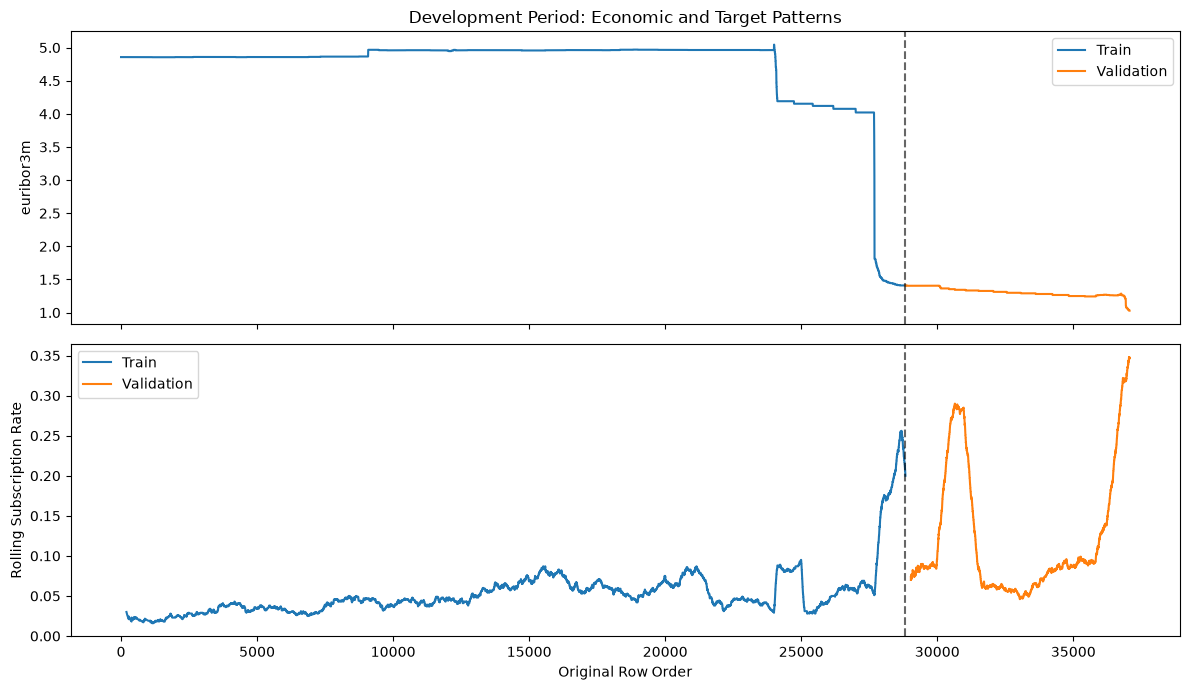

In [41]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
)

for label, split_df in [
    ("Train", train_df),
    ("Validation", valid_df),
]:
    axes[0].plot(
        split_df.index,
        split_df["euribor3m"],
        label=label,
    )

    rolling_subscription_rate = (
        split_df[target]
        .eq("yes")
        .astype(int)
        .rolling(window=1_000, min_periods=200)
        .mean()
    )

    axes[1].plot(
        split_df.index,
        rolling_subscription_rate,
        label=label,
    )

for ax in axes:
    ax.axvline(
        train_end - 0.5,
        color="black",
        linestyle="--",
        alpha=0.6,
    )
    ax.legend()

axes[0].set_title("Development Period: Economic and Target Patterns")
axes[0].set_ylabel("euribor3m")

axes[1].set_ylabel("Rolling Subscription Rate")
axes[1].set_xlabel("Original Row Order")

plt.tight_layout()
plt.show()

#### Observations

The training subscription rate is approximately 5.57%, compared
with 13.86% in Validation.

The development periods therefore differ substantially in
target prevalence.

The plots help inspect how economic conditions and subscription
rates vary through the development period.

The rolling rate uses a trailing window of 1,000 observations
and is calculated separately within each partition. It is an
EDA diagnostic, not a modeling feature.

Row order represents chronological sequence, not equally spaced
calendar time.

### 3.5 Summary & Decisions

- Retain 19 candidate predictors and exclude `duration`.
- Preserve the chronological split: 28,831 / 8,238 / 4,119 rows.
- Fit learned preprocessing and model parameters on Train only
  during development.
- Use Validation for model comparison and tuning.
- Interpret evaluation results alongside temporal distribution shift.

The test target distribution was previously inspected at an
aggregate level during EDA. From this point onward, the test set
is frozen for final evaluation.

The following EDA uses Train only.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Data Quality Assessment

Inspect:

- Pandas-recognized missing values.
- Explicit `"unknown"` categories.
- Exact duplicate observations.
- The sentinel structure of `pdays`.

The numerical and categorical lists below are dtype-based EDA
groups. Model-specific preprocessing groups will be defined
in Notebook 02.

In [42]:
numeric_predictors = (
    train_df[modeling_features]
    .select_dtypes(include="number")
    .columns.tolist()
)

categorical_predictors = (
    train_df[modeling_features]
    .select_dtypes(include=["object", "string", "category"])
    .columns.tolist()
)

print(f"Numerical candidate predictors: {len(numeric_predictors)}")
print(f"Categorical candidate predictors: {len(categorical_predictors)}")

Numerical candidate predictors: 9
Categorical candidate predictors: 10


In [43]:
missing_counts = train_df.isna().sum()
duplicate_count = train_df.duplicated().sum()

print(f"Missing values in Train: {missing_counts.sum()}")
print(f"Exact duplicate rows in Train: {duplicate_count}")

display(
    missing_counts[missing_counts > 0]
    .rename("missing_count")
    .to_frame()
)

Missing values in Train: 0
Exact duplicate rows in Train: 9


,missing_count


In [44]:
unknown_counts = (
    train_df[categorical_predictors]
    .eq("unknown")
    .sum()
)

unknown_summary = pd.DataFrame(
    {
        "count": unknown_counts,
        "rate": unknown_counts / len(train_df),
    }
)

unknown_summary = (
    unknown_summary
    .loc[unknown_summary["count"] > 0]
    .sort_values("rate", ascending=False)
)

unknown_summary

,count,rate
default,7302,0.253269
education,1183,0.041032
housing,694,0.024071
loan,694,0.024071
job,249,0.008637
marital,49,0.001700


In [45]:
pdays_summary = (
    train_df["pdays"]
    .eq(999)
    .value_counts()
    .reindex([True, False], fill_value=0)
    .rename_axis("pdays_is_999")
    .rename("count")
    .to_frame()
)

pdays_summary["proportion"] = (
    pdays_summary["count"] / len(train_df)
)

display(pdays_summary)

display(
    train_df.loc[train_df["pdays"].ne(999), "pdays"]
    .describe(percentiles=[0.50, 0.95, 0.99])
    .rename("pdays_excluding_999")
    .to_frame()
)

,count,proportion
pdays_is_999,,
True,28778,0.998162
False,53,0.001838


,pdays_excluding_999
count,53.000000
mean,4.924528
std,2.525631
min,0.000000
50%,5.000000
95%,9.400000
99%,10.480000
max,11.000000


#### Observations

- No pandas-recognized missing values were found in Train.
- `"unknown"` is an explicit category rather than a pandas null value.
- `default` has the largest unknown proportion: approximately 25.33%.
- Nine exact duplicate rows were found in Train.

Exact duplicates are retained because identical recorded values
do not establish that two rows represent an erroneous duplicate.
Client identifiers and complete timestamps are unavailable.

`pdays = 999` accounts for approximately 99.82% of Train.
This is a sentinel value, not an observed 999-day interval.

Its relationship with other campaign-history variables is
examined in Section 4.5.

No cleaning, imputation, deduplication, or feature transformation
is performed in this section.

### 4.2 Target Analysis

Inspect training class counts and proportions.

The business objective requires effective customer ranking,
so evaluation should emphasize positive-class ranking and
performance under limited contact capacity.

In [46]:
target_counts = (
    train_df[target]
    .value_counts()
    .reindex(["no", "yes"], fill_value=0)
)

target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "proportion": target_counts / len(train_df),
    }
)

display(target_summary)

always_no_accuracy = train_df[target].eq("no").mean()

print(f"Always-no accuracy on Train: {always_no_accuracy:.2%}")

,count,proportion
y,,
no,27225,0.944296
yes,1606,0.055704


Always-no accuracy on Train: 94.43%


#### Observations & Evaluation Implications

Train contains:

- 27,225 non-subscribers: 94.43%.
- 1,606 subscribers: 5.57%.

Always predicting `no` would produce approximately 94.43%
training accuracy while identifying no subscribers.

This illustrates class imbalance; it does not establish or
train the modeling baseline.

The evaluation direction is:

| Metric | Role |
|---|---|
| Average Precision (AP) | Primary metric summarizing positive-class ranking performance through precision and recall. |
| ROC-AUC | Additional measure of discrimination between subscribers and non-subscribers. |
| Precision@K | Subscriber proportion among the top K ranked customers. |
| Recall@K | Proportion of all subscribers captured within the top K customers. |
| Lift@K | Precision@K divided by the subscription rate of the evaluated dataset. |
| Accuracy | Reference metric only. |

K must specify a contact capacity, such as the top 5%,
top 10%, or a fixed number of customers.

AP and Precision@K depend on target prevalence. Report the
subscription rate of the evaluated partition alongside them.

For Validation, the prevalence reference is approximately
13.86%, rather than the training rate of 5.57%.

The baseline model and common ranking evaluation protocol
will be established in Notebook 03.

### 4.3 Feature Distributions

#### 4.3.1 Numerical Features

Inspect scales, quantiles, concentration, and extreme values.

`pdays` is excluded from this ordinary numerical summary because
its sentinel structure was examined separately in Section 4.1.

Extreme values and skewness are descriptive findings.
They do not automatically justify removal or transformation.

In [47]:
distribution_features = [
    col
    for col in numeric_predictors
    if col != "pdays"
]

numeric_summary = (
    train_df[distribution_features]
    .describe(percentiles=[0.50, 0.95, 0.99])
    .T[["min", "50%", "95%", "99%", "max"]]
)

numeric_summary["unique_values"] = (
    train_df[distribution_features].nunique()
)

numeric_summary["zero_share"] = (
    train_df[distribution_features].eq(0).mean()
)

numeric_summary

,min,50%,95%,99%,max,unique_values,zero_share
age,18.000,39.000,57.000,59.000,95.000,63,0.000000
campaign,1.000,2.000,8.000,17.000,56.000,42,0.000000
previous,0.000,0.000,0.000,1.000,3.000,4,0.965246
emp.var.rate,-1.800,1.400,1.400,1.400,1.400,5,0.000000
cons.price.idx,92.756,93.918,94.465,94.465,94.465,9,0.000000
cons.conf.idx,-50.000,-41.800,-36.100,-36.100,-36.100,9,0.000000
euribor3m,1.410,4.957,4.967,4.968,5.045,93,0.000000
nr.employed,5099.100,5228.100,5228.100,5228.100,5228.100,5,0.000000


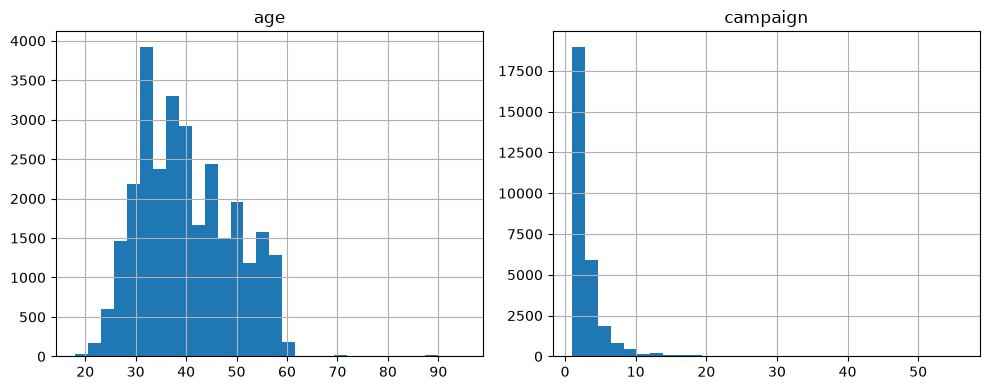

In [48]:
train_df[["age", "campaign"]].hist(
    bins=30,
    figsize=(10, 4),
)

plt.tight_layout()
plt.show()

#### 4.3.2 Categorical Features

Inspect category counts, dominant categories, and rare categories.

The 1% cutoff below is used only to describe category frequency.
It is not a rule for merging or removing categories.

In [49]:
categorical_summary_rows = []

for col in categorical_predictors:
    counts = train_df[col].value_counts()
    proportions = counts / len(train_df)

    categorical_summary_rows.append(
        {
            "feature": col,
            "n_categories": len(counts),
            "top_category": counts.index[0],
            "top_share": proportions.iloc[0],
            "smallest_category_count": counts.min(),
            "categories_below_1pct": (proportions < 0.01).sum(),
        }
    )

categorical_summary = (
    pd.DataFrame(categorical_summary_rows)
    .set_index("feature")
    .sort_values("n_categories", ascending=False)
)

categorical_summary

,n_categories,top_category,top_share,smallest_category_count,categories_below_1pct
feature,,,,,
job,12,admin.,0.246505,237,2
month,9,may,0.269259,10,3
education,8,university.degree,0.289445,14,1
day_of_week,5,thu,0.211196,5270,0
marital,4,married,0.631404,49,1
default,3,no,0.746627,3,1
loan,3,no,0.824599,694,0
housing,3,yes,0.508099,694,0
poutcome,3,nonexistent,0.965246,50,1


#### Observations

- `age` has a median of 39 and a maximum of 95.
- `campaign` is right-skewed, with a median of 2,
  a 99th percentile of 17, and a maximum of 56.
- `previous` is zero for approximately 96.52% of Train.
- Several macroeconomic predictors have relatively few unique values.
- Categorical predictors have low cardinality, but some categories
  have very few observations.
- Only nine month categories are observed in Train.

Numerical predictors differ in scale and distribution.
Categorical preprocessing must safely handle categories that
were not observed during training.

Keep unknown categories, rare categories, and extreme values
initially. Alternative treatments require modeling evidence
rather than distributional appearance alone.

### 4.4 Feature-Target Relationships

Examine training associations between candidate predictors
and subscription outcomes.

These are descriptive associations, not causal effects or
model-based feature importance.

No predictor is selected or removed solely from these results.

#### 4.4.1 Categorical Features vs Target

Report category counts, subscriber counts, and subscription rates.

Counts are essential because a high rate in a small category
may be unstable.

In [50]:
train_analysis = train_df.assign(
    y_yes=train_df[target].eq("yes").astype(int)
)

selected_categorical = [
    "job",
    "contact",
    "month",
    "poutcome",
]

for col in selected_categorical:
    summary = (
        train_analysis
        .groupby(col, observed=True)["y_yes"]
        .agg(
            count="size",
            subscribers="sum",
            subscription_rate="mean",
        )
        .sort_values("subscription_rate", ascending=False)
    )

    print(f"\nFeature: {col}")
    display(summary)


Feature: job


,count,subscribers,subscription_rate
job,,,
student,237,33,0.139241
retired,879,81,0.092150
management,2096,127,0.060592
self-employed,1043,62,0.059444
admin.,7107,416,0.058534
entrepreneur,1105,60,0.054299
technician,5054,271,0.053621
unknown,249,13,0.052209
services,2826,143,0.050602



Feature: contact


,count,subscribers,subscription_rate
contact,,,
cellular,15038,1051,0.069890
telephone,13793,555,0.040238



Feature: month


,count,subscribers,subscription_rate
month,,,
oct,67,42,0.626866
mar,282,126,0.446809
apr,859,141,0.164144
dec,10,1,0.100000
jul,6685,407,0.060883
nov,3616,190,0.052544
aug,5175,271,0.052367
jun,4374,188,0.042981
may,7763,240,0.030916



Feature: poutcome


,count,subscribers,subscription_rate
poutcome,,,
success,50,7,0.140000
failure,952,56,0.058824
nonexistent,27829,1543,0.055446


#### 4.4.2 Numerical Features vs Target

Compare selected numerical predictors across target classes.

Means and medians provide an initial summary but may conceal
nonlinear relationships or differences within subgroups.

Inspect the `pdays` sentinel groups separately.

The derived `y_yes` column is used only for analysis and is
not added to the candidate modeling feature list.

In [ ]:
selected_numeric = [
    "age",
    "campaign",
    "previous",
    "euribor3m",
    "nr.employed",
]

numeric_target_summary = (
    train_analysis
    .groupby(target)[selected_numeric]
    .agg(["mean", "median"])
    .T
)

numeric_target_summary

y                            no          yes
age         mean      40.218329    39.485056
            median    39.000000    37.000000
campaign    mean       2.785308     2.479452
            median     2.000000     2.000000
previous    mean       0.035556     0.041719
            median     0.000000     0.000000
euribor3m   mean       4.709733     4.274133
            median     4.957000     4.957000
nr.employed mean    5209.595581  5196.411083
            median  5228.100000  5228.100000

In [32]:
pdays_target_summary = (
    train_analysis
    .assign(pdays_is_999=train_analysis["pdays"].eq(999))
    .groupby("pdays_is_999")["y_yes"]
    .agg(
        count="size",
        subscribers="sum",
        subscription_rate="mean",
    )
)

pdays_target_summary

,count,subscribers,subscription_rate
pdays_is_999,,,
False,53,8,0.150943
True,28778,1598,0.055529


#### 4.4.3 Observations

- Subscription rates differ across jobs and contact channels.
- `cellular` has a training subscription rate of approximately
  6.99%, compared with 4.02% for `telephone`.
- Month-level rates vary substantially, but month also reflects
  the temporal conditions represented in the data.
- `poutcome = success` has a subscription rate of 14.00%,
  based on only 50 training observations.
- The `pdays != 999` group contains only 53 observations,
  including eight subscribers.

Small groups provide limited evidence about stable predictive
relationships.

The numerical summaries also show differences in macroeconomic
conditions between target classes. These may reflect temporal
patterns and should not be interpreted as causal effects.

Feature usefulness will be assessed through validation-based
modeling experiments.

### 4.5 Feature Relationships

#### 4.5.1 Macroeconomic Feature Correlations

Inspect Pearson correlations among macroeconomic predictors.

Correlations describe relationships within the training period;
they may differ in later periods.

High correlation alone is not a sufficient reason to remove
a predictor.

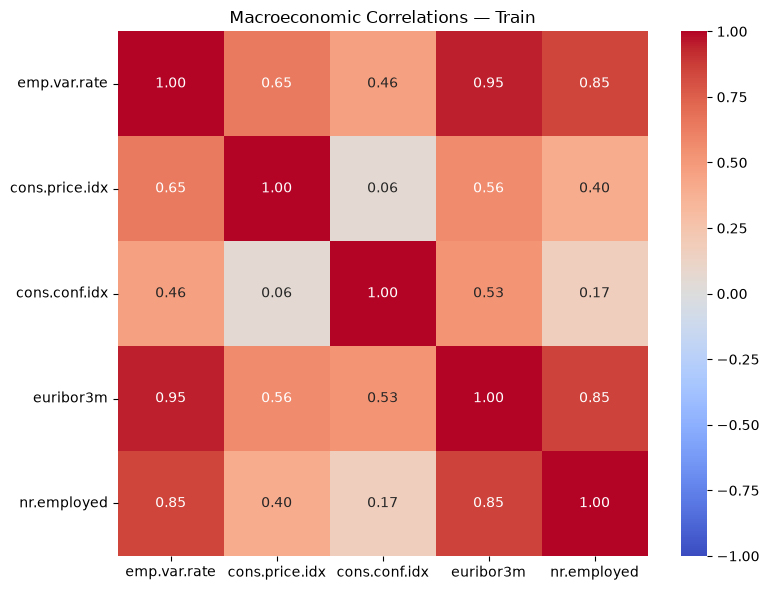

In [53]:
macro_features = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]

macro_corr = train_df[macro_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    macro_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Macroeconomic Correlations — Train")
plt.tight_layout()
plt.show()

#### 4.5.2 Previous Campaign History Relationships

Inspect the joint structure of:

- `previous`: contacts performed before the current campaign.
- `poutcome`: the outcome of the previous campaign.
- `pdays`: the recorded interval since a previous campaign contact,
  including the sentinel value `999`.

Check their observed relationships rather than assuming these
variables are interchangeable.

In [54]:
history_summary = pd.crosstab(
    index=train_df["poutcome"],
    columns=[
        train_df["previous"].gt(0),
        train_df["pdays"].eq(999),
    ],
    rownames=["poutcome"],
    colnames=["previous > 0", "pdays = 999"],
)

history_summary

previous > 0  False True       
pdays = 999   True  False True 
poutcome                       
failure           0     3   949
nonexistent   27829     0     0
success           0    50     0

#### 4.5.3 Observations

**Macroeconomic predictors**

Several macroeconomic predictors are strongly correlated.
For example, the training correlation between `emp.var.rate`
and `euribor3m` is approximately 0.95.

These predictors may capture overlapping economic and temporal
information. Strong correlations can complicate interpretation
of individual linear-model coefficients.

**Previous campaign history**

In Train, `poutcome = nonexistent` corresponds to `previous = 0`.

However, 949 observations have both `previous > 0` and
`pdays = 999`. The sentinel indicator therefore cannot be used
as a direct replacement for the observed previous-contact indicator.

Treat this as a semantic limitation requiring documentation.
Do not infer corrected values or overwrite the history variables.

The three history predictors are related but contain different
recorded information.

No predictors are removed because of these relationships.
Their predictive contribution and alternative representations
will be evaluated in Notebook 04.

## 5. Findings & Summary

This notebook established the feature availability assumptions,
chronological split, and training-data findings required for
subsequent preprocessing and modeling.

### 5.1 Key Findings

| Area | Finding | Implication |
|---|---|---|
| Missing values | No pandas-recognized missing values in Train. | No imputation requirement was identified from this inspection. |
| Unknown categories | `default` contains approximately 25.33% `"unknown"`. | Retain unknown values as explicit categories initially. |
| Exact duplicates | Nine exact duplicate training rows. | Retain them because erroneous duplication cannot be established. |
| Target imbalance | Train subscription rate is 5.57%. | Accuracy alone is insufficient for the ranking objective. |
| Temporal shift | Validation subscription rate is 13.86%. | Interpret metrics alongside the evaluated period and prevalence. |
| Numerical distributions | Different scales, skewness, and concentrated values. | Establish a simple baseline before testing alternative transformations. |
| Sparse history groups | Only 53 training rows have `pdays != 999`. | Avoid strong conclusions from small-group rates. |
| Feature relationships | Strong macroeconomic correlations and related campaign-history variables. | Do not remove predictors solely from EDA associations. |

### 5.2 Decisions & Limitations

**Feature availability**

- Prediction time is immediately before a planned marketing contact.
- Exclude `duration` from modeling while retaining it in the raw data.
- Retain the other 19 predictors as candidates.
- Retain `campaign` and `contact` under the documented workflow assumptions.

**Data usage**

- Preserve the chronological 70/20/10 split:
  - Train: 28,831 rows.
  - Validation: 8,238 rows.
  - Test: 4,119 rows.
- Fit learned preprocessing and models on Train only during development.
- Use Validation for comparison, tuning, and selection.
- From this point onward, Test is frozen for final evaluation.

**Preprocessing direction**

- Preserve `"unknown"` categories initially.
- Handle unseen categorical values safely.
- Do not automatically clip extreme values, merge rare categories,
  or remove correlated predictors.
- Preserve the raw campaign-history values and document the
  sentinel structure of `pdays`.

**Evaluation direction**

- Use Average Precision as the primary model-selection metric.
- Report ROC-AUC and business-oriented ranking metrics:
  Precision@K, Recall@K, and Lift@K.
- Make the contact capacity K explicit.
- Report target prevalence for the evaluated dataset.
- Treat accuracy as a reference metric.

**Known limitations**

- Client identifiers are unavailable, so client overlap between
  partitions cannot be verified.
- Complete timestamps are unavailable, so exact date boundaries
  and publication-time availability cannot be independently checked.
- A single chronological validation period provides limited
  evidence about performance across other future periods.
- Small history and categorical groups produce uncertain estimates.
- The semantics of `pdays = 999` cannot be fully resolved from
  the available predictors.

### 5.3 Next Steps

Notebook 02 will:

1. Reload the raw data and reproduce the established split.
2. Define numerical, categorical, and special feature groups.
3. Implement a simple baseline preprocessing strategy.
4. Fit preprocessing on Train and transform Validation.
5. Verify the transformed structure and unseen-category handling.

Notebook 03 will define, train, and evaluate the baseline model.

Notebook 04 will compare alternative feature representations,
preprocessing choices, model families, and hyperparameters.

No model is selected or trained in this notebook, and no
performance-based preprocessing comparison is performed here.